In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, f1_score

In [2]:
train_data = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

test_data = fetch_20newsgroups(
    subset="test"
)

X_train = train_data.data
y_train = train_data.target

X_test = test_data.data
y_test = test_data.target

print("Training documents:", len(X_train))
print("Testing documents:", len(X_test))
print("Number of classes:", len(train_data.target_names))

print("\nFirst document:")
print(X_train[0][:500])

Training documents: 11314
Testing documents: 7532
Number of classes: 20

First document:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


In [4]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20000
)

X_train_count = vectorizer.fit_transform(X_train)
X_test_count = vectorizer.transform(X_test)

print("Training feature shape:", X_train_count.shape)
print("Testing feature shape:", X_test_count.shape)

Training feature shape: (11314, 20000)
Testing feature shape: (7532, 20000)


In [5]:
mnb = MultinomialNB()

mnb.fit(X_train_count, y_train)

y_pred_mnb = mnb.predict(X_test_count)

accuracy_mnb = accuracy_score(y_test, y_pred_mnb)

f1_mnb = f1_score(
    y_test,
    y_pred_mnb,
    average="weighted"
)

print("Multinomial Naive Bayes")
print("-----------------------")
print("Accuracy :", accuracy_mnb)
print("F1-Score :", f1_mnb)

Multinomial Naive Bayes
-----------------------
Accuracy : 0.7217206585236325
F1-Score : 0.7058368549746614


In [6]:
X_train_binary = (X_train_count > 0).astype(int)
X_test_binary = (X_test_count > 0).astype(int)

bnb = BernoulliNB()

bnb.fit(X_train_binary, y_train)

y_pred_bnb = bnb.predict(X_test_binary)

accuracy_bnb = accuracy_score(y_test, y_pred_bnb)

f1_bnb = f1_score(
    y_test,
    y_pred_bnb,
    average="weighted"
)

print("Bernoulli Naive Bayes")
print("---------------------")
print("Accuracy :", accuracy_bnb)
print("F1-Score :", f1_bnb)

Bernoulli Naive Bayes
---------------------
Accuracy : 0.6821561338289963
F1-Score : 0.6657608014225777


In [7]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Bernoulli Naive Bayes"
    ],
    "Accuracy": [
        accuracy_mnb,
        accuracy_bnb
    ],
    "F1-Score": [
        f1_mnb,
        f1_bnb
    ]
})

print(results)

                     Model  Accuracy  F1-Score
0  Multinomial Naive Bayes  0.721721  0.705837
1    Bernoulli Naive Bayes  0.682156  0.665761


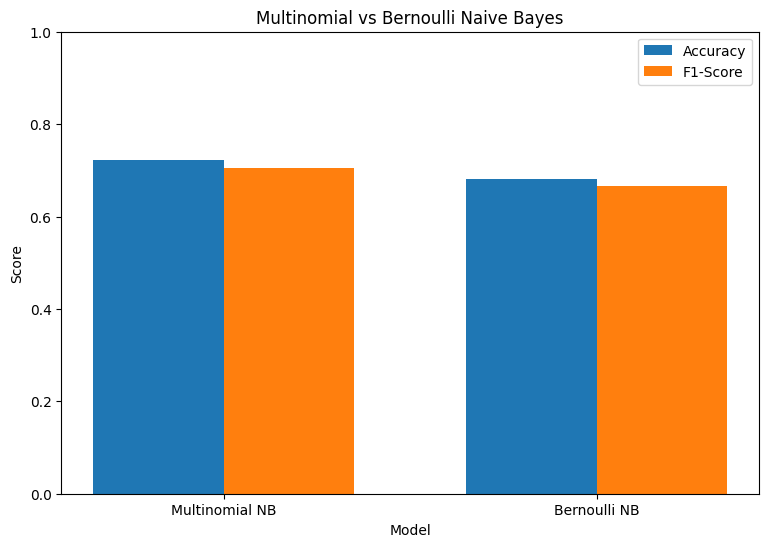

In [8]:
x = np.arange(2)
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width / 2,
    [accuracy_mnb, accuracy_bnb],
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    [f1_mnb, f1_bnb],
    width,
    label="F1-Score"
)

plt.xticks(
    x,
    ["Multinomial NB", "Bernoulli NB"]
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Multinomial vs Bernoulli Naive Bayes")
plt.ylim(0, 1)
plt.legend()

plt.show()